**Ameen Khan
22070521007**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

In [5]:
# Set a style for all plots
sns.set(style="whitegrid")
print("--- Libraries Imported Successfully ---")

--- Libraries Imported Successfully ---


In [6]:
# STEP 1: LOAD THE DATASET
print("\n--- Step 1: Loading Data ---")
df = pd.read_csv('/content/housing[1].csv')

df = df.rename(columns={'MedInc': 'median_income'})

print("Data loaded.")
print(df[['median_income', 'median_house_value']].head())


--- Step 1: Loading Data ---
Data loaded.
   median_income  median_house_value
0         8.3252            452600.0
1         8.3014            358500.0
2         7.2574            352100.0
3         5.6431            341300.0
4         3.8462            342200.0



--- Step 2: Basic Data Preprocessing & Cleaning ---

Checking for missing values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
-> This dataset has missing values in total_bedrooms, but we are not using that for model building. So no action needed.

Checking for duplicate rows: 0 found.
-> This dataset has no duplicate rows. No action needed.

Displaying boxplot to check for outliers in 'median_income'...


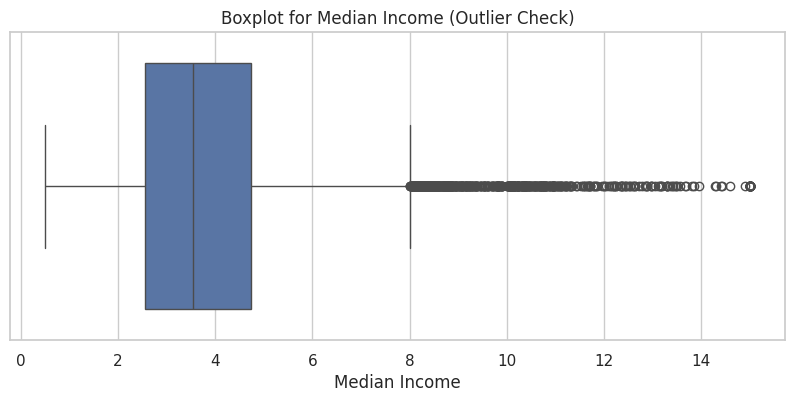

-> Preprocessing check complete.


In [7]:
# STEP 2: BASIC DATA PREPROCESSING & CLEANING
print("\n--- Step 2: Basic Data Preprocessing & Cleaning ---")

print("\nChecking for missing values:")
print(df.isnull().sum())
print("-> This dataset has missing values in total_bedrooms, but we are not using that for model building. So no action needed.")

duplicate_count = df.duplicated().sum()
print(f"\nChecking for duplicate rows: {duplicate_count} found.")
print("-> This dataset has no duplicate rows. No action needed.")

print("\nDisplaying boxplot to check for outliers in 'median_income'...")
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['median_income'])
plt.title('Boxplot for Median Income (Outlier Check)')
plt.xlabel('Median Income')
plt.show()

print("-> Preprocessing check complete.")

In [8]:
# STEP 3: DEFINE DEPENDENT (y) AND INDEPENDENT (X) VARIABLES
print("\n--- Step 3: Defining Variables ---")

y = df['median_house_value']

X = df[['median_income']]

print(f"Dependent variable (y) shape: {y.shape}")
print(f"Independent variable (X) shape: {X.shape}")


--- Step 3: Defining Variables ---
Dependent variable (y) shape: (20640,)
Independent variable (X) shape: (20640, 1)



--- Step 4: Exploratory Data Analysis (EDA) ---


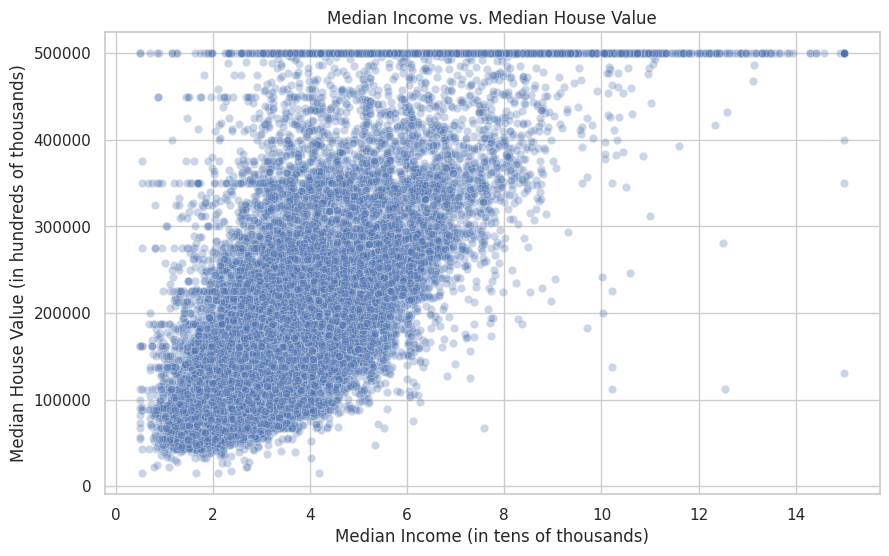

Displaying distributions of our variables...


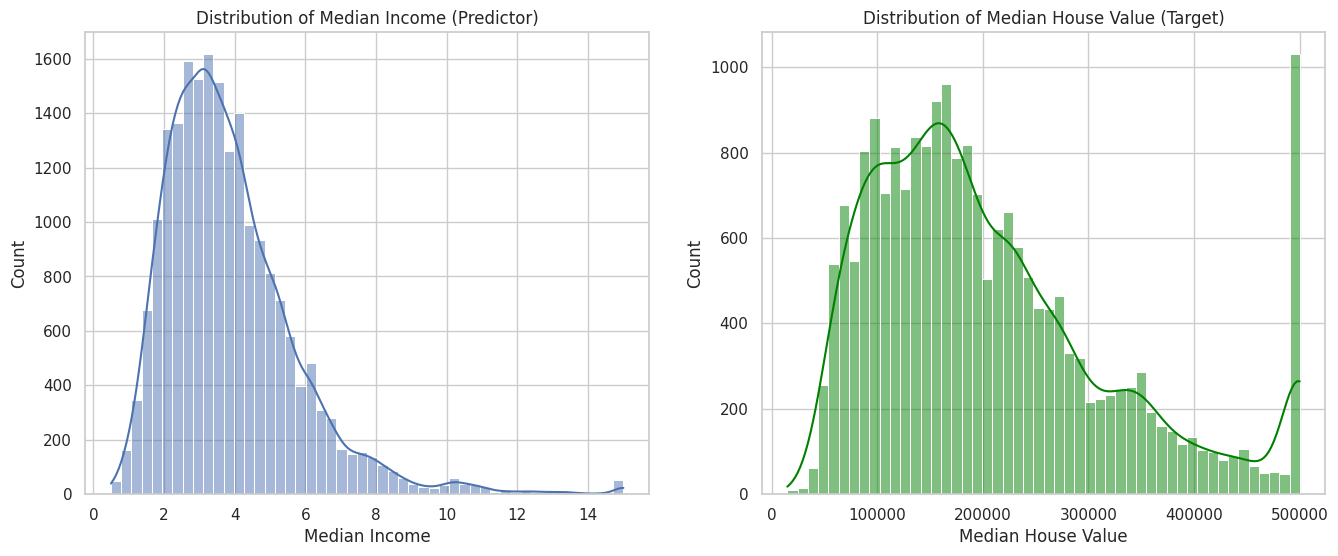

EDA plots displayed.
Note the cap in House Value at 5.0 and Income at 15.0


In [9]:
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)
print("\n--- Step 4: Exploratory Data Analysis (EDA) ---")

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X['median_income'], y=y, alpha=0.3)
plt.title('Median Income vs. Median House Value')
plt.xlabel('Median Income (in tens of thousands)')
plt.ylabel('Median House Value (in hundreds of thousands)')
plt.show()

print("Displaying distributions of our variables...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(X['median_income'], kde=True, bins=50, ax=ax1)
ax1.set_title('Distribution of Median Income (Predictor)')
ax1.set_xlabel('Median Income')

sns.histplot(y, kde=True, bins=50, ax=ax2, color='green')
ax2.set_title('Distribution of Median House Value (Target)')
ax2.set_xlabel('Median House Value')
plt.show()

print("EDA plots displayed.")
print("Note the cap in House Value at 5.0 and Income at 15.0")

In [10]:
# STEP 5: SPLIT DATA INTO TRAINING AND TEST SETS
print("\n--- Step 5: Splitting Data ---")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


--- Step 5: Splitting Data ---
Training set size: 16512 samples
Test set size: 4128 samples


In [11]:
# STEP 6: MODEL BUILDING AND TRAINING
print("\n--- Step 6: Building and Training the Model ---")

simple_model = LinearRegression()

simple_model.fit(X_train, y_train)

print("Model training complete.")


--- Step 6: Building and Training the Model ---
Model training complete.



--- Step 7: Evaluating the Model ---

--- Model's Learned Equation ---
Regression Equation:  y_predicted = 44459.7292 + (41933.8494 * median_income)
---
Model Intercept (b0): 44459.7292
Model Coefficient (b1) for 'median_income': 41933.8494

--- Model Performance Metrics ---
R-squared (R²): 0.4589
  -> 'median_income' alone explains ~45.9% of the variance in 'median_house_value'.
Root Mean Squared Error (RMSE): $8,420,901,241.41
  -> On average, the model's predictions are off by about $8,420,901,241.41.

Displaying Residuals Plot...


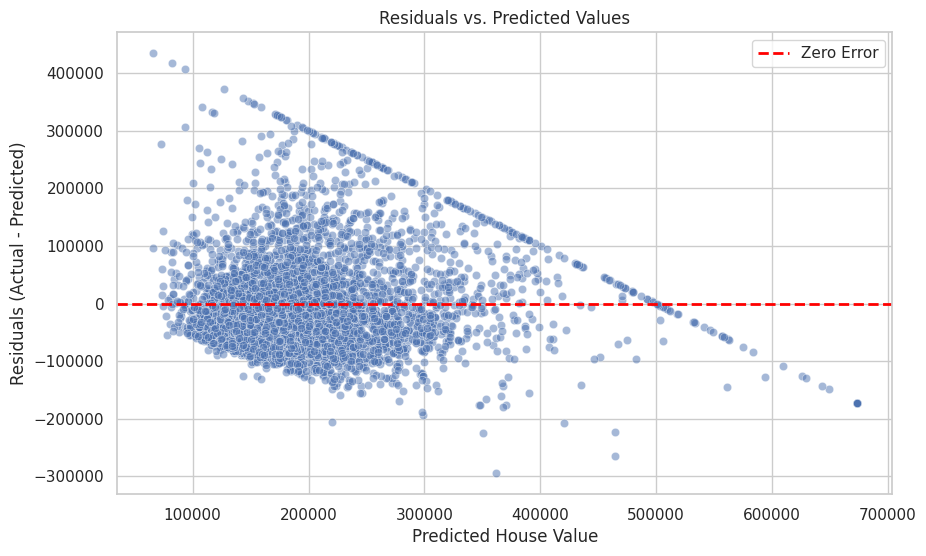

-> A good residuals plot should be a random cloud of points around y=0.
   We can see a pattern (a funnel shape), which suggests
   that a simple linear model may not be the best fit for this data.


In [12]:
# STEP 7: MODEL EVALUATION
print("\n--- Step 7: Evaluating the Model ---")

y_pred = simple_model.predict(X_test)

intercept = simple_model.intercept_
coefficient = simple_model.coef_[0]

print("\n--- Model's Learned Equation ---")
print(f"Regression Equation:  y_predicted = {intercept:.4f} + ({coefficient:.4f} * median_income)")
print("---")
print(f"Model Intercept (b0): {intercept:.4f}")
print(f"Model Coefficient (b1) for 'median_income': {coefficient:.4f}")

y_test_dollars = y_test * 100000
y_pred_dollars = y_pred * 100000

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test_dollars, y_pred_dollars)
rmse = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))

print("\n--- Model Performance Metrics ---")
print(f"R-squared (R²): {r2:.4f}")
print(f"  -> 'median_income' alone explains ~{r2*100:.1f}% of the variance in 'median_house_value'.")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"  -> On average, the model's predictions are off by about ${rmse:,.2f}.")

print("\nDisplaying Residuals Plot...")
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted House Value')
plt.ylabel('Residuals (Actual - Predicted)')
plt.legend()
plt.show()

print("-> A good residuals plot should be a random cloud of points around y=0.")
print("   We can see a pattern (a funnel shape), which suggests")
print("   that a simple linear model may not be the best fit for this data.")


--- Step 8: Visualizing the Regression Line ---


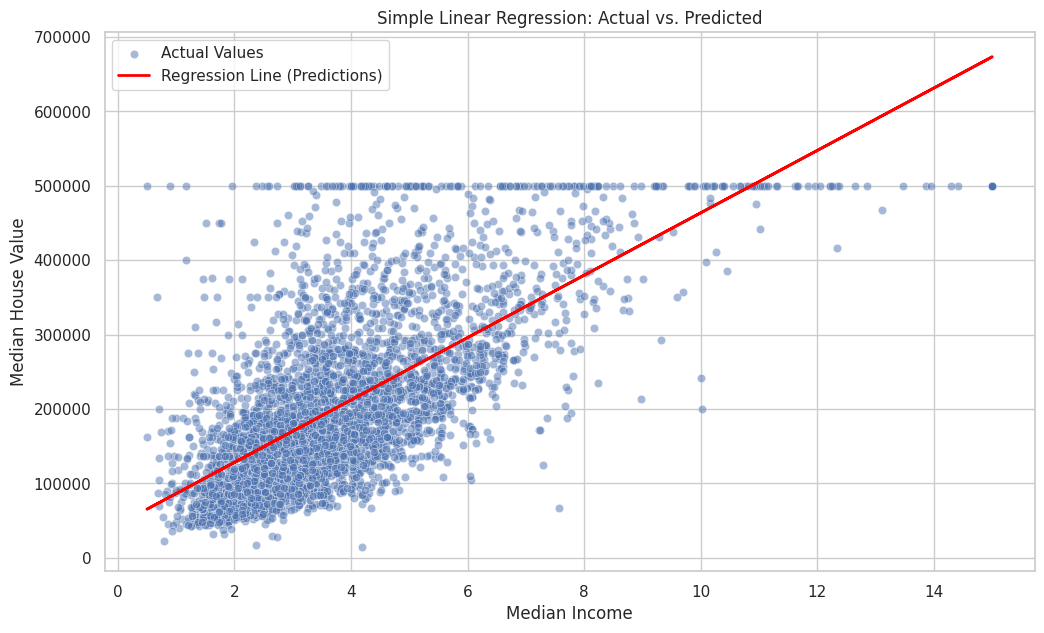

Result visualization displayed.


In [13]:
# STEP 8: VISUALIZE THE REGRESSION LINE
print("\n--- Step 8: Visualizing the Regression Line ---")

plt.figure(figsize=(12, 7))
sns.scatterplot(x=X_test['median_income'], y=y_test, alpha=0.5, label='Actual Values')
plt.plot(X_test['median_income'], y_pred, color='red', linewidth=2, label='Regression Line (Predictions)')
plt.title('Simple Linear Regression: Actual vs. Predicted')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.show()

print("Result visualization displayed.")

In [14]:
# STEP 9: SAVE THE MODEL
print("\n--- Step 9: Saving the Model ---")

model_filename = 'simple_linear_regression_model.joblib'
joblib.dump(simple_model, model_filename)

print(f"Model saved successfully to: {model_filename}")


--- Step 9: Saving the Model ---
Model saved successfully to: simple_linear_regression_model.joblib


In [15]:
# STEP 10: LOAD AND USE THE MODEL (EXAMPLE)
print("\n--- Step 10: Loading and Using the Saved Model ---")

loaded_model = joblib.load(model_filename)
print("Model loaded successfully.")

new_incomes = pd.DataFrame({'median_income': [3.5, 8.1, 1.5]})

predicted_prices = loaded_model.predict(new_incomes)

print("\n--- Example Prediction ---")
for i, income in enumerate(new_incomes['median_income']):
    predicted_price_dollars = predicted_prices[i] * 100000
    print(f"For a median income of ${income*10000:,.2f}, the predicted house value is ${predicted_price_dollars:,.2f}")



--- Step 10: Loading and Using the Saved Model ---
Model loaded successfully.

--- Example Prediction ---
For a median income of $35,000.00, the predicted house value is $19,122,820,204.74
For a median income of $81,000.00, the predicted house value is $38,412,390,925.90
For a median income of $15,000.00, the predicted house value is $10,736,050,325.98
